# Modes of Variability: Pattern and Teleconnection Maps

Select one mode, season/frequency, and input method. The workflow then loads or computes the data, saves raw-analysis caches when needed, and creates both regional mode-pattern and global teleconnection figures.


In [55]:
from pathlib import Path
import importlib
import sys

import numpy as np
import xarray as xr
from scipy.stats import ttest_rel

PROJECT_ROOT = next((p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "scripts").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find the repository scripts directory.")
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from environment import configure_proj_data
configure_proj_data(verbose=True)

import mov_config
import pcmdi_mov_workflow
importlib.reload(mov_config)
importlib.reload(pcmdi_mov_workflow)
from movs_analyzer import ModeAnalyzer
from movs_plotter import ExtrapropicalModeMapPlotter
from pcmdi_mov_reader import EMOVDiagReader
from pcmdi_mov_workflow import run_mode_pattern_workflow


[INFO] Using PROJ data: /lcrc/soft/climate/e3sm-unified/e3smu_1_12_0/chrysalis/conda/envs/e3sm_unified_1.12.0_login/share/proj


In [56]:
# Shared paths, mode registry, and figure options.
MOV_PCMDI_DATA_DIR = Path("/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi")
MOV_RAW_DATA_ROOT = mov_config.DEFAULT_MODEL_DATA_ROOT
MOV_OUT_DIR = Path("/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper")
MOV_MODE_CONFIG = {key: dict(value) for key, value in mov_config.MODE_CONFIG.items()}

# Shared figure settings. Significance options apply only to method="raw";
# PCMDI products are plotted without stippling because they do not provide
# the raw resamples/p-value maps required for this test.
MOV_PATTERN_CONFIG = dict(
    which="eof", filename_template="{mode}_{token}_{var}_{eof}_MODE_PATTERN_region.pdf",
    lon_convention="negpos", central_lon=0.0, ncols=2, figsize_per_panel=(5.2, 3.6),
    fontz=16, fig_dpi=300, fig_format="pdf", xtick_step=20.0, wspace=0.15, hspace=0.40, cb_pad=0.10,
    cmap="RdBu_r", mlevels=np.arange(-5, 6, dtype=float), cbar_ticks=np.arange(-5, 6, dtype=float),
    cbar_label="EOF amplitude", area_weight=True, show_significance=True, sig_level=0.05, dot_density=2, dot_size=3,
)
MOV_TELECONNECTION_CONFIG = dict(
    which="slope", raw_var="slope_proj", filename_template="{mode}_{token}_{var}_{eof}_TELECONNECTION_global.pdf",
    central_lon=180.0, ncols=2, figsize_per_panel=(6.0, 4.0), fontz=18, fig_dpi=300, fig_format="pdf",
    xtick_step=60.0, yticks=np.arange(-90, 91, 30), wspace=0.15, hspace=0.40, cb_pad=0.08,
    cmap="RdBu_r", mlevels=np.linspace(-3, 3, 13), cbar_ticks=np.arange(-3, 4),
    cbar_label="Regression coefficient", area_weight=True, show_significance=True, sig_level=0.05, dot_density=4, dot_size=8,
)


In [57]:
def run_mov_comparison(
    experiments, *, method, mode, token, period, overwrite=False,
    pcmdi_data_dir=MOV_PCMDI_DATA_DIR, out_dir=MOV_OUT_DIR,
):
    """Build the selected backend and plot mode and teleconnection maps."""
    method = str(method).lower()
    if method not in {"raw", "pcmdi"}:
        raise ValueError("method must be 'raw' or 'pcmdi'")
    if not experiments:
        raise ValueError("At least one MOVExperiment is required")

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    model_keys = [experiment.key for experiment in experiments]
    model_labels = [experiment.label for experiment in experiments]
    pcmdi_model_tags = [experiment.pcmdi_tag for experiment in experiments]
    raw_model_datasets = mov_config.experiments_to_raw_datasets(experiments)

    obs_dataset_map = {name: cfg["obs"] for name, cfg in MOV_MODE_CONFIG.items()}
    pcmdi_reader = EMOVDiagReader(
        data_dir=str(pcmdi_data_dir), prefer_cbf=True, obs_key="obs", model_key="e3sm",
        target_lat_name="latitude", target_lon_name="longitude_a",
        obs_dataset_map=obs_dataset_map, normalize_lon_360=True, sort_latlon=True,
    )

    raw_mode_config = {}
    for name, cfg in MOV_MODE_CONFIG.items():
        item = dict(cfg)
        item.update(
            type="eof", eof_num=int(str(cfg["eof"]).replace("eof", "")),
            obs=dict(mov_config.OBS_SOURCES[cfg["var"]]),
        )
        raw_mode_config[name] = item
    analyzer = ModeAnalyzer({"datasets": raw_model_datasets, "modes": raw_mode_config})

    lat_name, lon_name = ("latitude", "longitude_a") if method == "pcmdi" else ("lat", "lon")
    map_plotter = ExtrapropicalModeMapPlotter(
        fig_dir=str(out_dir),
        plot_dict={"reference": {"label": "Obs"}, "hist": {"label": "Models"}},
        group_order=("hist",), obs_key="reference", lat_name=lat_name, lon_name=lon_name,
    )

    outputs = run_mode_pattern_workflow(
        method=method, mode=mode, token=token, period=period, mode_dict=MOV_MODE_CONFIG,
        model_labels=model_labels, map_plotter=map_plotter, pattern_config=MOV_PATTERN_CONFIG,
        teleconnection_config=MOV_TELECONNECTION_CONFIG, pcmdi_reader=pcmdi_reader,
        pcmdi_model_tags=pcmdi_model_tags, analyzer=analyzer, raw_model_names=model_keys,
        data_dir=str(out_dir), overwrite=overwrite,
    )
    print(f"Completed {method} workflow for {mode}/{token}: {model_labels}")
    return outputs


  Loading obs from cache: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper/NAO_DJF_1985-2014_NOAA-20C_NOAA-20C.nc
  PCMDI read_data_in unavailable for this input (argument of type 'PosixPath' is not iterable); using xarray reader.
  Loading LR from cache: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper/NAO_DJF_1985-2014_NOAA-20C_LR.nc
  Loading NARRM from cache: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper/NAO_DJF_1985-2014_NOAA-20C_NARRM.nc
  Loading NARRM_r0125 from cache: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper/NAO_DJF_1985-2014_NOAA-20C_NARRM_r0125.nc
  Loading EARRM from cache: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper/NAO_DJF_1985-2014_NOAA-20C_EARRM.nc
  Loading AMZRRM from cache: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper/NAO_DJF_1985-2014_NOAA-20C_AMZRRM.nc
Saved: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper/

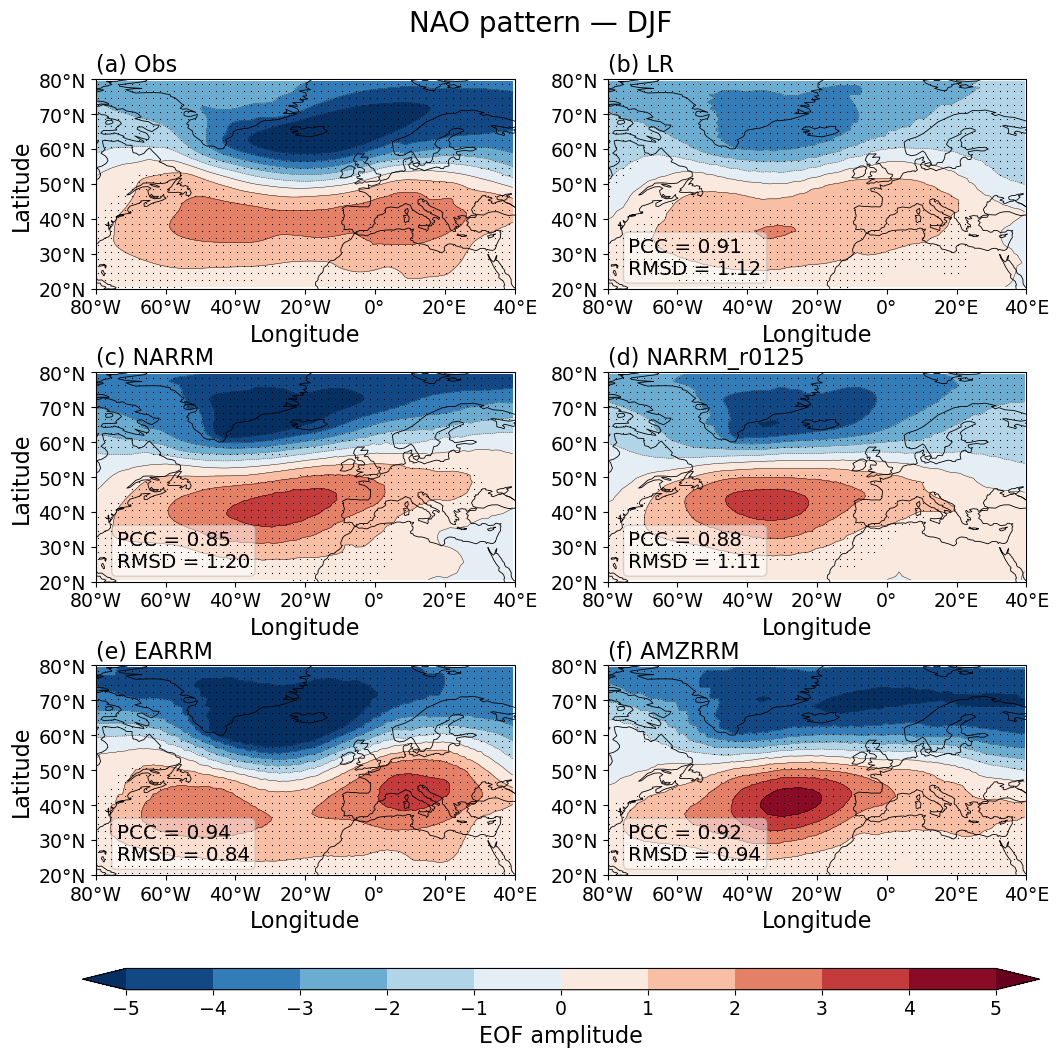

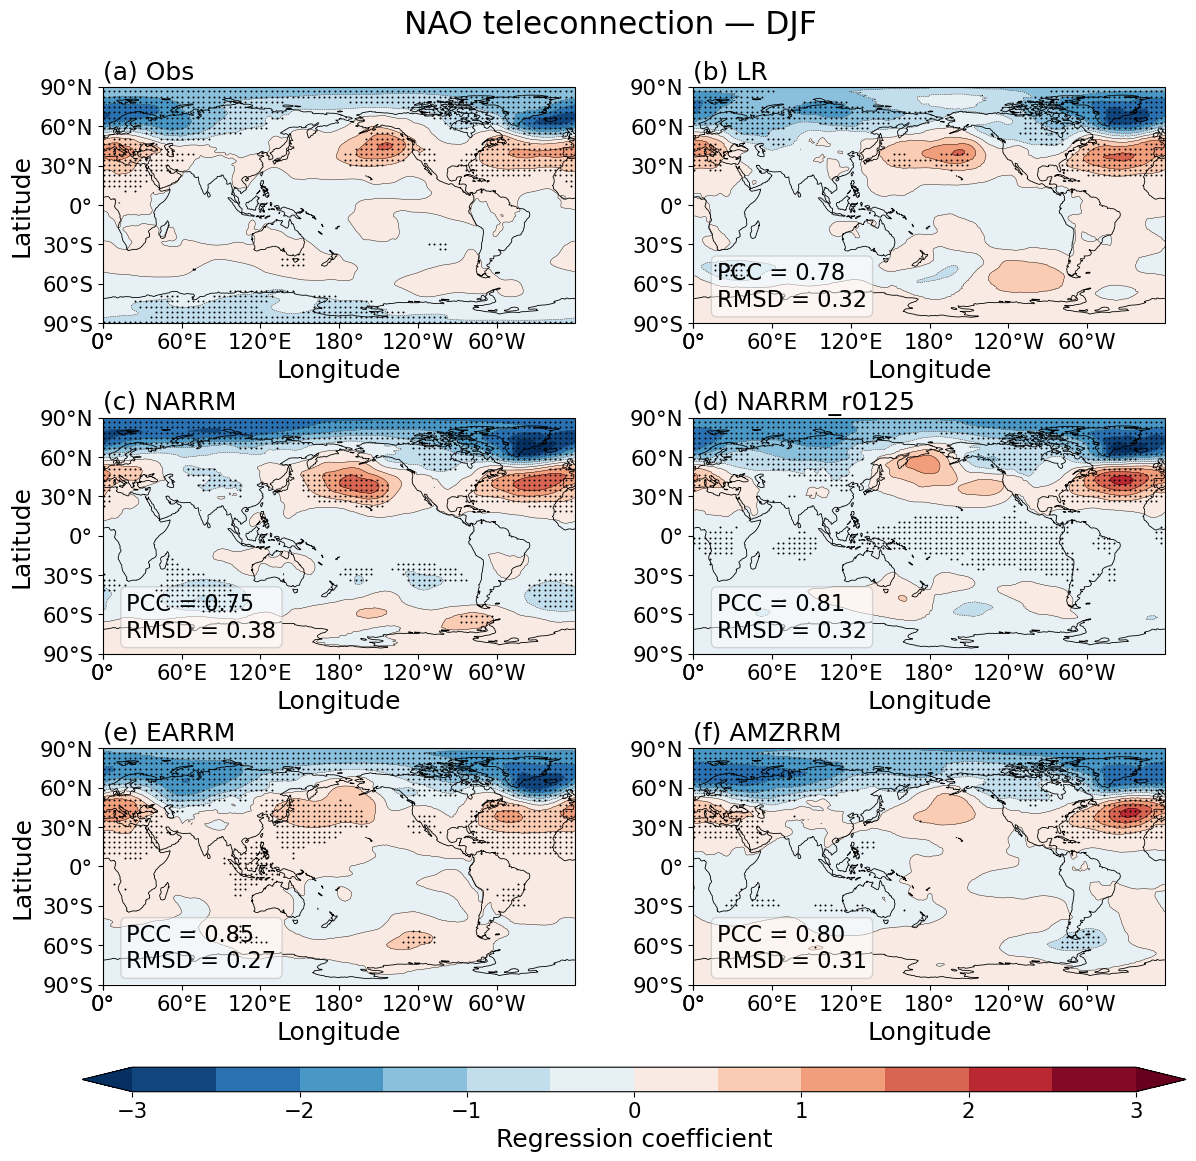

In [58]:
# Experiment setup and plot. Edit this cell for a new comparison.
MOV_RUN_WORKFLOW = True
MOV_METHOD = "raw"  # "raw" (default, supports significance) or "pcmdi"
MOV_MODE = "NAO"
MOV_TOKEN = "DJF"  # PSL: DJF/MAM/JJA/SON/monthly/yearly; SST: monthly/yearly
MOV_PERIOD = mov_config.DEFAULT_PERIOD
MOV_OVERWRITE_RAW_DATA = False

MOV_COMPARISON_EXPERIMENTS = [
    mov_config.MOVExperiment(key="LR", label="LR", model_name="v3.LR.amip_0101", pcmdi_tag="v3.LR.amip_0101", data_root=MOV_RAW_DATA_ROOT),
    mov_config.MOVExperiment(key="NARRM", label="NARRM", model_name="v3.NARRM.amip_0101", pcmdi_tag="v3.NARRM.amip_0101", data_root=MOV_RAW_DATA_ROOT),
    mov_config.MOVExperiment(key="NARRM_r0125", label="NARRM_r0125", model_name="v3.NARRM_r0125.amip_0101", pcmdi_tag="v3.NARRM_r0125.amip_0101", data_root=MOV_RAW_DATA_ROOT),
    mov_config.MOVExperiment(key="EARRM", label="EARRM", model_name="v3.EARRM.amip_0101", pcmdi_tag="v3.EARRM.amip_0101", data_root=MOV_RAW_DATA_ROOT),
    mov_config.MOVExperiment(key="AMZRRM", label="AMZRRM", model_name="v3.AMZRRM.amip_0101", pcmdi_tag="v3.AMZRRM.amip_0101", data_root=MOV_RAW_DATA_ROOT),
]

if MOV_RUN_WORKFLOW:
    mov_outputs = run_mov_comparison(
        MOV_COMPARISON_EXPERIMENTS, method=MOV_METHOD, mode=MOV_MODE, token=MOV_TOKEN,
        period=MOV_PERIOD, overwrite=MOV_OVERWRITE_RAW_DATA,
    )
else:
    print("Set MOV_RUN_WORKFLOW = True after reviewing this experiment cell.")


NAO overlay: spread
v3.LR Historical: 25 members, period=(1980, 2014)
v3.LR Near-Future: 25 members, period=(2015, 2049)
Saved: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/paper_plot/NAO_DJF_v3LR_hist_vs_future_MODE_PATTERN_spread.pdf
Saved: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/paper_plot/NAO_DJF_v3LR_hist_vs_future_TELECONNECTION_spread.pdf


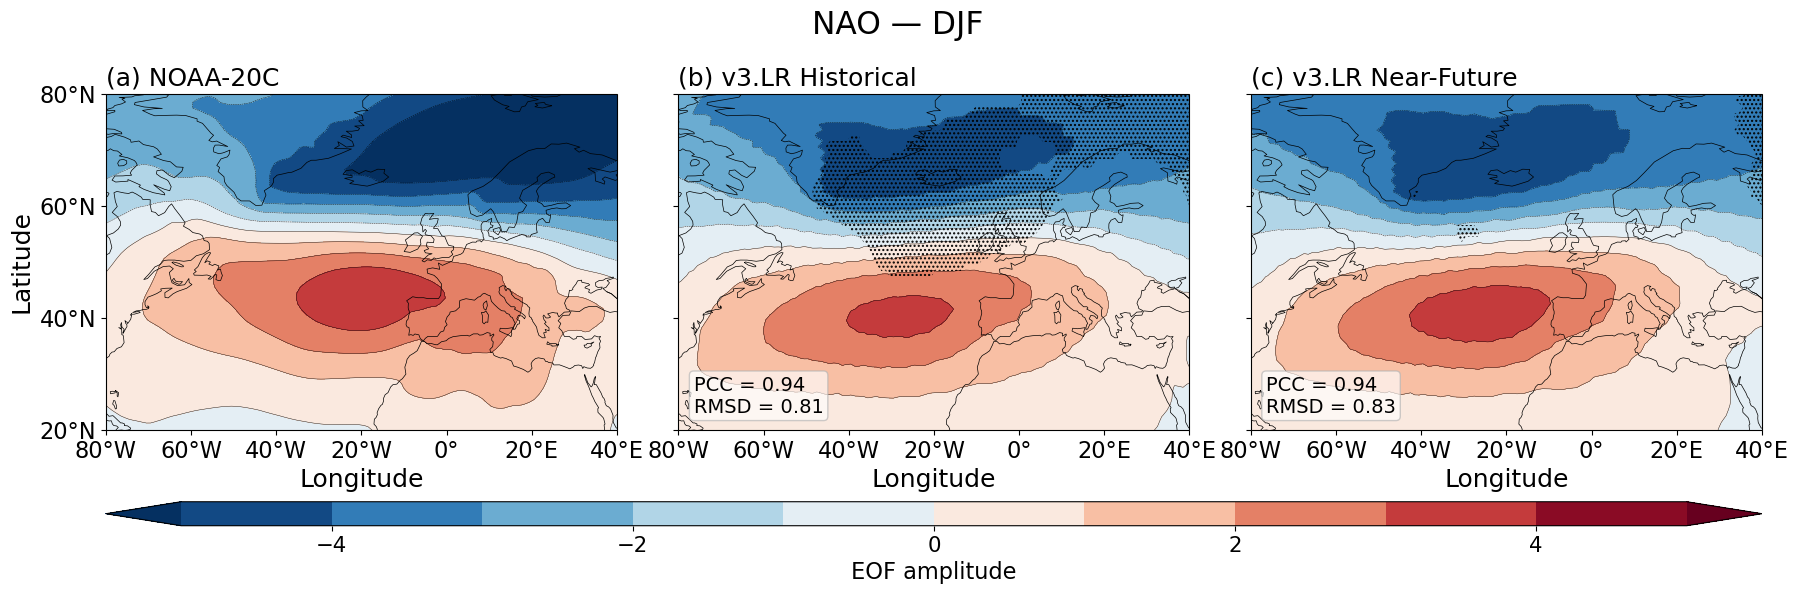

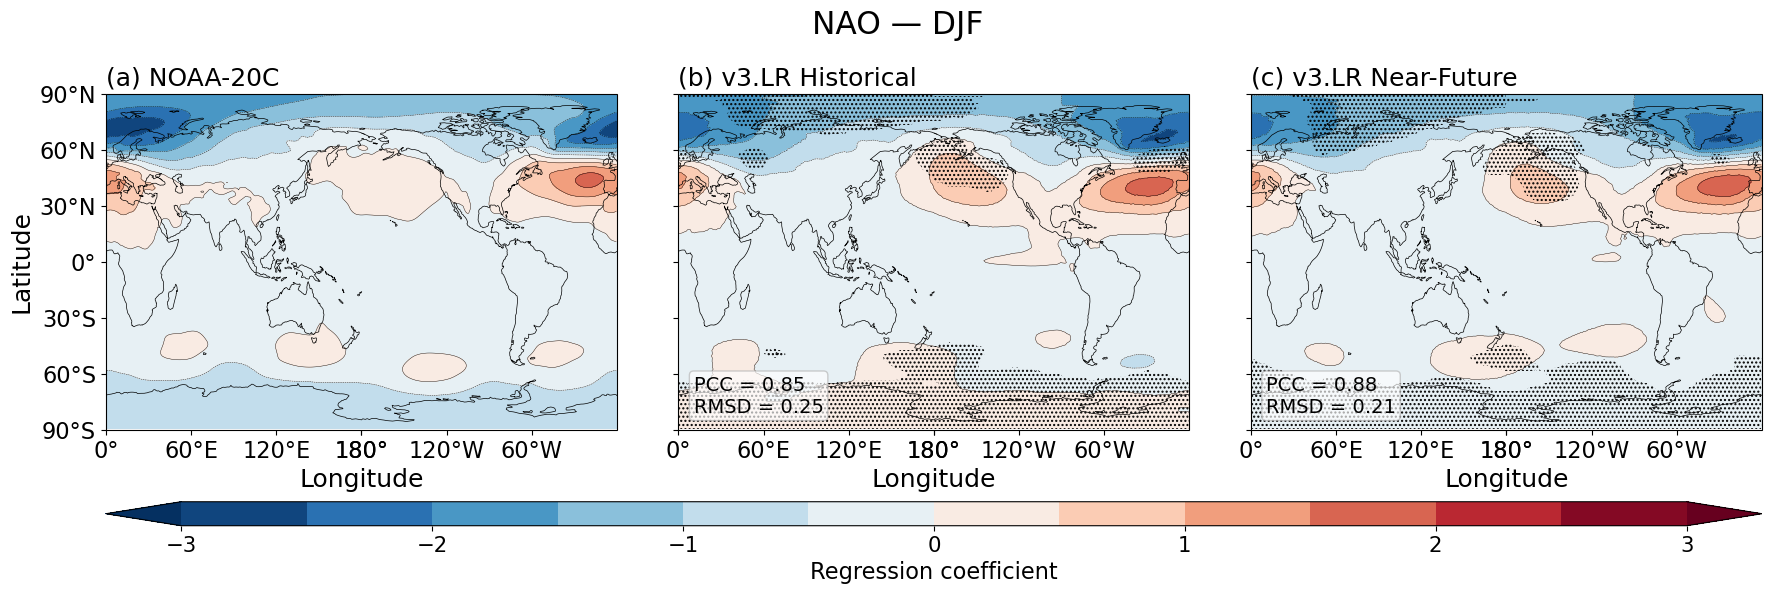

In [59]:
# v3.LR historical versus near-future NAO comparison (25 members per group).
RUN_HIST_FUTURE_NAO = True
NAO_MODE = "NAO"
NAO_TOKEN = "DJF"
NAO_MEMBER_GLOB = "v3.LR.historical_*"
NAO_EXPECTED_NENS = 25
NAO_HIST_PERIOD = (1980, 2014)
NAO_FUTURE_PERIOD = (2015, 2049)
NAO_OVERLAY = "spread"  # "significance", "spread", or "none"
NAO_SIGNIFICANCE_LEVEL = 0.05
NAO_SPREAD_QUANTILE = 0.75  # Stipple where ensemble std exceeds this spatial quantile.
NAO_STATS_FONT_SCALE = 0.78  # PCC/RMSD size relative to the base font.
NAO_DATA_DIR = Path("/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le")
NAO_HIST_DIR = NAO_DATA_DIR / "hist"
NAO_FUTURE_DIR = NAO_DATA_DIR / "future"
NAO_FIG_DIR = NAO_DATA_DIR / "paper_plot"

# Figure inputs: edit these dictionaries instead of the plotting calls below.
NAO_PATTERN_FIGURE_OPTIONS = dict(
    extent=(-80, 40, 20, 80), central_lon=0.0,
    figsize=(18, 6), fontz=18,
    xtick_step=20.0, yticks=np.arange(20, 81, 20),
    mlevels_by_product={"pattern": MOV_PATTERN_CONFIG["mlevels"]},
    cb_labels_by_product={"pattern": MOV_PATTERN_CONFIG["cbar_label"]},
    sig_level=NAO_SIGNIFICANCE_LEVEL, sig_dot_density=2, sig_dot_size=2.0,
    overlay_spread=NAO_OVERLAY == "spread", spread_quantile=NAO_SPREAD_QUANTILE,
    annotate_stats=True, stats_area_weight=True, stats_font_scale=NAO_STATS_FONT_SCALE,
    fig_format="pdf", fig_dpi=300,
    top=0.84, bottom=0.28, wspace=0.12, hide_inner_ylabels=True,
    row_cbar_pad=0.16, row_cbar_height=0.040,
)
NAO_TELECONNECTION_FIGURE_OPTIONS = dict(
    extent=(-180, 180, -90, 90), central_lon=180.0,
    figsize=(18, 6), fontz=18,
    xtick_step=60.0, yticks=np.arange(-90, 91, 30),
    mlevels_by_product={"teleconnection": MOV_TELECONNECTION_CONFIG["mlevels"]},
    cb_labels_by_product={"teleconnection": MOV_TELECONNECTION_CONFIG["cbar_label"]},
    sig_level=NAO_SIGNIFICANCE_LEVEL, sig_dot_density=3, sig_dot_size=2.0,
    overlay_spread=NAO_OVERLAY == "spread", spread_quantile=NAO_SPREAD_QUANTILE,
    annotate_stats=True, stats_area_weight=True, stats_font_scale=NAO_STATS_FONT_SCALE,
    fig_format="pdf", fig_dpi=300,
    top=0.84, bottom=0.28, wspace=0.12, hide_inner_ylabels=True,
    row_cbar_pad=0.16, row_cbar_height=0.040,
)

NAO_GROUPS = {
    "hist": {"label": "v3.LR Historical", "data_dir": NAO_HIST_DIR, "period": NAO_HIST_PERIOD},
    "future": {"label": "v3.LR Near-Future", "data_dir": NAO_FUTURE_DIR, "period": NAO_FUTURE_PERIOD},
}

def _member_tags(data_dir, pattern, expected_nens):
    tags = sorted(path.name for path in Path(data_dir).glob(pattern) if path.is_dir())
    if len(tags) != expected_nens:
        raise RuntimeError(f"Expected {expected_nens} members under {data_dir}, found {len(tags)}")
    return tags

def _pcmdi_group_stack(reader, member_tags, spec, which):
    maps = [reader.read_model_variable(tag, spec, which=which) for tag in member_tags]
    return xr.concat(maps, dim="member").assign_coords(member=member_tags)

def _fdr_adjust(pvalue):
    """Benjamini-Hochberg adjusted p-values, preserving the map shape."""
    values = np.asarray(pvalue, dtype=float)
    adjusted = np.full(values.shape, np.nan, dtype=float)
    valid = np.isfinite(values)
    flat = values[valid]
    if flat.size:
        order = np.argsort(flat)
        ranked = flat[order] * flat.size / np.arange(1, flat.size + 1)
        ranked = np.minimum.accumulate(ranked[::-1])[::-1]
        restored = np.empty_like(ranked)
        restored[order] = np.clip(ranked, 0.0, 1.0)
        adjusted[valid] = restored
    return adjusted

def _paired_fdr_pvalue(hist_stack, future_stack):
    """Paired grid-point test across matching ensemble-member IDs."""
    hist_stack, future_stack = xr.align(hist_stack, future_stack, join="exact")
    result = ttest_rel(future_stack.values, hist_stack.values, axis=0, nan_policy="omit")
    template = hist_stack.isel(member=0, drop=True)
    return xr.DataArray(_fdr_adjust(result.pvalue), coords=template.coords, dims=template.dims)

def _wrap_longitude_negpos(data_array):
    """Move 0–360 data to a monotonic −180–180 grid for regional maps."""
    lon_name = "longitude_a"
    longitude = ((data_array[lon_name] + 180.0) % 360.0) - 180.0
    return data_array.assign_coords({lon_name: longitude}).sortby(lon_name)

if RUN_HIST_FUTURE_NAO:
    if NAO_OVERLAY not in {"significance", "spread", "none"}:
        raise ValueError("NAO_OVERLAY must be 'significance', 'spread', or 'none'")
    print(f"NAO overlay: {NAO_OVERLAY}")
    NAO_FIG_DIR.mkdir(parents=True, exist_ok=True)
    nao_cfg = MOV_MODE_CONFIG[NAO_MODE]
    nao_readers = {}
    nao_specs = {}
    nao_members = {}
    for group, cfg in NAO_GROUPS.items():
        nao_members[group] = _member_tags(cfg["data_dir"], NAO_MEMBER_GLOB, NAO_EXPECTED_NENS)
        nao_readers[group] = EMOVDiagReader(
            data_dir=str(cfg["data_dir"]), prefer_cbf=True, obs_key="obs", model_key="e3sm",
            target_lat_name="latitude", target_lon_name="longitude_a",
            obs_dataset_map={NAO_MODE: nao_cfg["obs"]}, normalize_lon_360=True, sort_latlon=True,
        )
        _, nao_specs[group] = pcmdi_mov_workflow.resolve_mode_spec(
            MOV_MODE_CONFIG, NAO_MODE, NAO_TOKEN, cfg["period"],
        )
        print(f"{cfg['label']}: {len(nao_members[group])} members, period={cfg['period']}")

    # Observation is stored with the historical diagnostics; future files use the future period only for models.
    nao_reference = nao_readers["hist"].read_reference_map(
        nao_members["hist"][0], nao_specs["hist"], which="eof",
    )
    nao_products = {}
    for product, which in {"pattern": "eof", "teleconnection": "slope"}.items():
        reference = nao_reference if which == "eof" else nao_readers["hist"].read_reference_map(
            nao_members["hist"][0], nao_specs["hist"], which=which,
        )
        nao_products[product] = {
            "reference": reference,
            "hist": _pcmdi_group_stack(nao_readers["hist"], nao_members["hist"], nao_specs["hist"], which),
            "future": _pcmdi_group_stack(nao_readers["future"], nao_members["future"], nao_specs["future"], which),
        }
    nao_significance = {}
    for product, data in nao_products.items():
        pvalue = _paired_fdr_pvalue(data["hist"], data["future"])
        # The same future-minus-historical test is shown on both ensemble panels.
        nao_significance[product] = {"hist": pvalue, "future": pvalue}
    nao_pattern_data = {key: _wrap_longitude_negpos(value) for key, value in nao_products["pattern"].items()}
    nao_pattern_significance = {
        key: _wrap_longitude_negpos(value) for key, value in nao_significance["pattern"].items()
    }

    nao_plotter = ExtrapropicalModeMapPlotter(
        fig_dir=str(NAO_FIG_DIR),
        plot_dict={
            "reference": {"label": "NOAA-20C"},
            "hist": {"label": NAO_GROUPS["hist"]["label"]},
            "future": {"label": NAO_GROUPS["future"]["label"]},
        },
        group_order=("hist", "future"), obs_key="reference",
        lat_name="latitude", lon_name="longitude_a",
    )
    nao_pattern_figure = nao_plotter.plot_mode_season_maps(
        mode=NAO_MODE, season=NAO_TOKEN, products={"pattern": nao_pattern_data},
        product_labels={"pattern": ""},
        filename=f"NAO_DJF_v3LR_hist_vs_future_MODE_PATTERN_{NAO_OVERLAY}.pdf",
        significance_by_product=(
            {"pattern": nao_pattern_significance}
            if NAO_OVERLAY == "significance" else None
        ),
        **NAO_PATTERN_FIGURE_OPTIONS,
    )
    nao_teleconnection_figure = nao_plotter.plot_mode_season_maps(
        mode=NAO_MODE, season=NAO_TOKEN, products={"teleconnection": nao_products["teleconnection"]},
        product_labels={"teleconnection": ""},
        filename=f"NAO_DJF_v3LR_hist_vs_future_TELECONNECTION_{NAO_OVERLAY}.pdf",
        significance_by_product=(
            {"teleconnection": nao_significance["teleconnection"]}
            if NAO_OVERLAY == "significance" else None
        ),
        **NAO_TELECONNECTION_FIGURE_OPTIONS,
    )
else:
    print("Set RUN_HIST_FUTURE_NAO = True to run the v3.LR ensemble comparison.")
